# An AI-Based Environmental Intelligence System for Sustainability

Wind-speed forecasting (LSTM), air-pollution forecasting (Random Forest), and zero-shot ESG text classification, applied to the Beijing PM2.5 dataset (Liang et al., 2015). Temporal splits are strictly chronological, scalers are fitted on training data only, and metrics are reported in original physical units. A persistence baseline and a feature-ablation contrast the marginal contribution of the wind-speed forecast within the air-pollution model.

## 1. Setup

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})


## 2. Data

The Beijing PM2.5 dataset (Liang et al., 2015; UCI Machine Learning Repository) contains hourly meteorological and air-quality measurements taken at the United States Embassy in Beijing between 1 January 2010 and 31 December 2014, totalling 43,824 records. The variables used in this study are summarised below.

| Variable | Description | Units |
|---|---|---|
| `pm2.5` | fine particulate matter concentration | µg/m³ |
| `DEWP` | dew point | °C |
| `TEMP` | air temperature | °C |
| `PRES` | atmospheric pressure | hPa |
| `cbwd` | combined wind direction (NW, NE, SE, cv) | — |
| `Iws` | cumulative wind speed | m/s |
| `Is`  | cumulative hours of snow | h |
| `Ir`  | cumulative hours of rain | h |

Records with missing PM2.5 (concentrated in the early months of 2010) were removed, and the categorical wind-direction column was one-hot encoded.

In [33]:
DATA_DIR = Path("data")
df = pd.read_csv(DATA_DIR / "PRSA_data_2010.1.1-2014.12.31.csv")
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.sort_values("datetime").reset_index(drop=True)
df = df.dropna(subset=["pm2.5"]).reset_index(drop=True)
df = pd.get_dummies(df, columns=["cbwd"], drop_first=True, dtype=float)
cbwd_cols = [c for c in df.columns if c.startswith("cbwd_")]

print(f"Records: {len(df):,}   Span: {df.datetime.min().date()} – {df.datetime.max().date()}")
df[["pm2.5", "DEWP", "TEMP", "PRES", "Iws"]].describe().round(2)


Records: 41,757   Span: 2010-01-02 – 2014-12-31


,pm2.5,DEWP,TEMP,PRES,Iws
count,41757.00,41757.00,41757.00,41757.00,41757.00
mean,98.61,1.75,12.40,1016.44,23.87
std,92.05,14.43,12.18,10.30,49.62
min,0.00,-40.00,-19.00,991.00,0.45
25%,29.00,-10.00,2.00,1008.00,1.79
50%,72.00,2.00,14.00,1016.00,5.37
75%,137.00,15.00,23.00,1025.00,21.91
max,994.00,28.00,42.00,1046.00,565.49


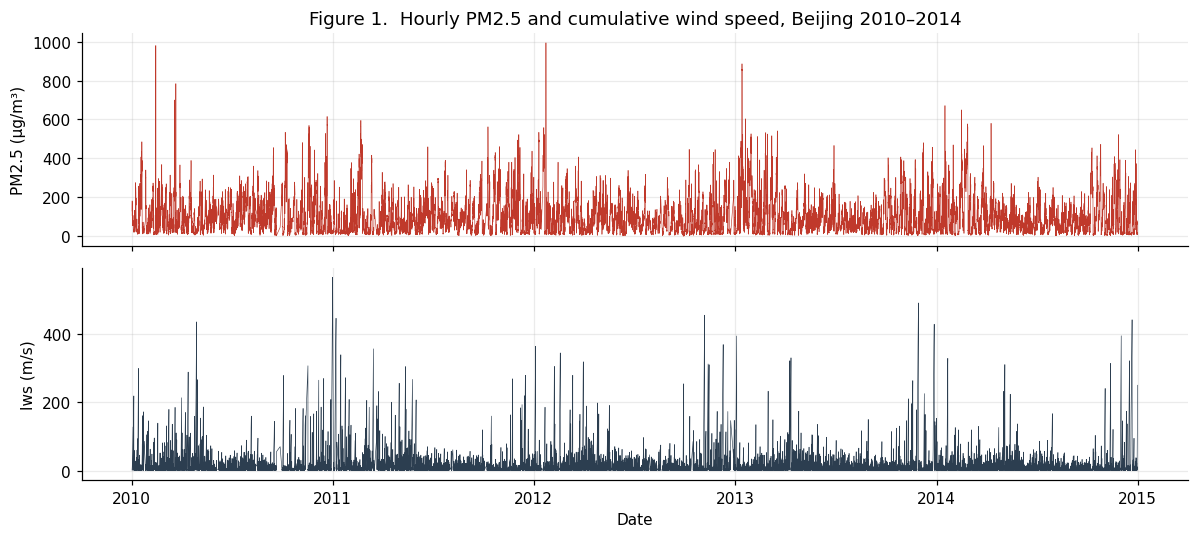

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(df["datetime"], df["pm2.5"], lw=0.4, color="#C0392B")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_title("Figure 1.  Hourly PM2.5 and cumulative wind speed, Beijing 2010–2014")
axes[1].plot(df["datetime"], df["Iws"], lw=0.4, color="#2C3E50")
axes[1].set_ylabel("Iws (m/s)"); axes[1].set_xlabel("Date")
plt.tight_layout(); plt.show()


## 3. Wind-Speed Forecasting (LSTM)

A two-layer Long Short-Term Memory network was trained to forecast cumulative wind speed (`Iws`) one hour ahead from the preceding 24 hours of `[DEWP, TEMP, PRES, Iws]`. The dataset was partitioned chronologically into 70 % training, 15 % validation, and 15 % test segments. Min-max scalers were fitted on the training segment only and applied to the validation and test segments. The model was trained for 15 epochs with the Adam optimiser (learning rate 1 × 10⁻³) and mini-batches of 256 sequences.

In [35]:
SEQ_LEN, BATCH = 24, 256
wind_features, target = ["DEWP", "TEMP", "PRES", "Iws"], "Iws"

n = len(df)
train_end = int(0.70 * n)
X_raw = df[wind_features].values.astype(np.float32)
y_raw = df[[target]].values.astype(np.float32)

sx = MinMaxScaler().fit(X_raw[:train_end])
sy = MinMaxScaler().fit(y_raw[:train_end])
X_scaled = sx.transform(X_raw); y_scaled = sy.transform(y_raw)

def make_sequences(X, y, L):
    Xs, ys = [], []
    for i in range(len(X) - L):
        Xs.append(X[i:i+L]); ys.append(y[i+L])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN)
tr, va = int(0.70 * len(X_seq)), int(0.85 * len(X_seq))
X_tr, X_va, X_te = X_seq[:tr], X_seq[tr:va], X_seq[va:]
y_tr, y_va, y_te = y_seq[:tr], y_seq[tr:va], y_seq[va:]

t = lambda a: torch.tensor(a, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(t(X_tr), t(y_tr)), batch_size=BATCH, shuffle=False)
val_loader   = DataLoader(TensorDataset(t(X_va), t(y_va)), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(TensorDataset(t(X_te), t(y_te)), batch_size=BATCH, shuffle=False)


In [36]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

lstm_model = LSTMRegressor(input_size=len(wind_features)).to(device)
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

EPOCHS = 15
train_losses, val_losses = [], []
for epoch in range(1, EPOCHS + 1):
    lstm_model.train(); tot = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward(); optimizer.step()
        tot += loss.item() * len(xb)
    train_losses.append(tot / len(train_loader.dataset))

    lstm_model.eval(); tot = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            tot += criterion(lstm_model(xb), yb).item() * len(xb)
    val_losses.append(tot / len(val_loader.dataset))
    print(f"Epoch {epoch:02d}/{EPOCHS}   train MSE = {train_losses[-1]:.5f}   val MSE = {val_losses[-1]:.5f}")


Epoch 01/15   train MSE = 0.00703   val MSE = 0.00789
Epoch 02/15   train MSE = 0.00479   val MSE = 0.00663
Epoch 03/15   train MSE = 0.00309   val MSE = 0.00448
Epoch 04/15   train MSE = 0.00240   val MSE = 0.00179
Epoch 05/15   train MSE = 0.00154   val MSE = 0.00251
Epoch 06/15   train MSE = 0.00181   val MSE = 0.00311
Epoch 07/15   train MSE = 0.00153   val MSE = 0.00089
Epoch 08/15   train MSE = 0.00104   val MSE = 0.00085
Epoch 09/15   train MSE = 0.00100   val MSE = 0.00099
Epoch 10/15   train MSE = 0.00097   val MSE = 0.00118
Epoch 11/15   train MSE = 0.00106   val MSE = 0.00232
Epoch 12/15   train MSE = 0.00132   val MSE = 0.00380
Epoch 13/15   train MSE = 0.00149   val MSE = 0.00148
Epoch 14/15   train MSE = 0.00102   val MSE = 0.00076
Epoch 15/15   train MSE = 0.00089   val MSE = 0.00070


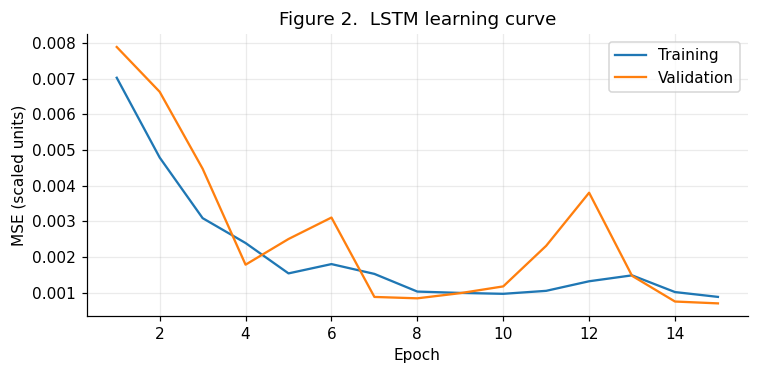

In [37]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(1, EPOCHS + 1), train_losses, label="Training")
ax.plot(range(1, EPOCHS + 1), val_losses,   label="Validation")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled units)")
ax.set_title("Figure 2.  LSTM learning curve")
ax.legend(); plt.tight_layout(); plt.show()


In [38]:
lstm_model.eval()
preds_scaled = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds_scaled.append(lstm_model(xb.to(device)).cpu().numpy())
preds_scaled = np.concatenate(preds_scaled, axis=0)
wind_pred = sy.inverse_transform(preds_scaled).flatten()
wind_true = sy.inverse_transform(y_te).flatten()

wind_rmse = float(np.sqrt(mean_squared_error(wind_true, wind_pred)))
wind_mae  = float(mean_absolute_error(wind_true, wind_pred))
wind_r2   = float(r2_score(wind_true, wind_pred))

pd.DataFrame({"Metric": ["RMSE (m/s)", "MAE (m/s)", "R²"],
              "Value": [round(wind_rmse, 3), round(wind_mae, 3), round(wind_r2, 3)]})


,Metric,Value
0,RMSE (m/s),14.400
1,MAE (m/s),5.945
2,R²,0.908


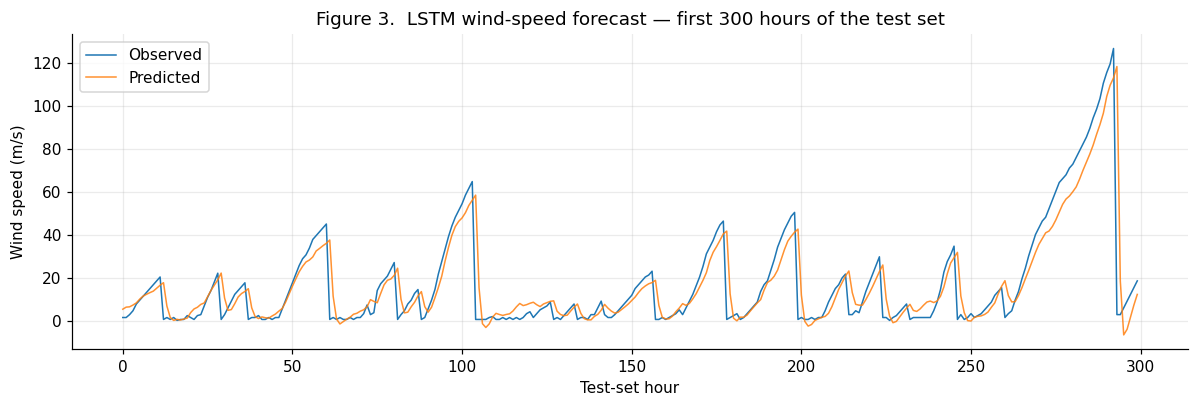

In [39]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(wind_true[:300], label="Observed",  lw=1.0)
ax.plot(wind_pred[:300], label="Predicted", lw=1.0, alpha=0.85)
ax.set_xlabel("Test-set hour"); ax.set_ylabel("Wind speed (m/s)")
ax.set_title("Figure 3.  LSTM wind-speed forecast — first 300 hours of the test set")
ax.legend(); plt.tight_layout(); plt.show()


## 4. Air-Pollution Forecasting (Random Forest)

Hourly PM2.5 was modelled using observed weather variables, two-step lag features (`pm_lag1`, `pm_lag2`), one-hot wind-direction indicators, and the LSTM's wind-speed forecast (`pred_Iws`) as an additional input. The data were partitioned chronologically into 80 % training and 20 % testing. Three configurations were evaluated on the same split: (i) a persistence baseline that predicts the previous hour's PM2.5; (ii) a Random Forest excluding `pred_Iws` (control); and (iii) a Random Forest including `pred_Iws` (full model). The contrast between (ii) and (iii) isolates the marginal contribution of the LSTM forecast.

In [40]:
# Generate LSTM forecasts for every valid sequence position so they can be
# aligned to dataframe rows: row i+SEQ_LEN receives the forecast computed
# from rows i..i+SEQ_LEN-1.
all_X = t(X_seq).to(device)
preds_full = []
with torch.no_grad():
    for i in range(0, len(all_X), 1024):
        preds_full.append(lstm_model(all_X[i:i+1024]).cpu().numpy())
preds_full = sy.inverse_transform(np.concatenate(preds_full, axis=0)).flatten()

df["pred_Iws"] = np.nan
df.loc[SEQ_LEN: SEQ_LEN + len(preds_full) - 1, "pred_Iws"] = preds_full
df["pm_lag1"] = df["pm2.5"].shift(1)
df["pm_lag2"] = df["pm2.5"].shift(2)

air_features = ["DEWP", "TEMP", "PRES", "Iws", "Is", "Ir",
                "pm_lag1", "pm_lag2", "pred_Iws"] + cbwd_cols
df_air = df.dropna(subset=air_features + ["pm2.5"]).reset_index(drop=True)

split = int(0.80 * len(df_air))
X_tr_a, X_te_a = df_air.iloc[:split][air_features], df_air.iloc[split:][air_features]
y_tr_a, y_te_a = df_air.iloc[:split]["pm2.5"],      df_air.iloc[split:]["pm2.5"]

print(f"Training: {len(X_tr_a):,} hours  ({df_air.iloc[0].datetime.date()} – {df_air.iloc[split-1].datetime.date()})")
print(f"Testing : {len(X_te_a):,} hours  ({df_air.iloc[split].datetime.date()} – {df_air.iloc[-1].datetime.date()})")


Training: 33,386 hours  (2010-01-03 – 2014-01-14)
Testing : 8,347 hours  (2014-01-14 – 2014-12-31)


In [41]:
# (i) Persistence baseline
y_persist = X_te_a["pm_lag1"].values
persist_rmse = float(np.sqrt(mean_squared_error(y_te_a, y_persist)))
persist_mae  = float(mean_absolute_error(y_te_a, y_persist))
persist_r2   = float(r2_score(y_te_a, y_persist))

# (ii) Random Forest without pred_Iws
features_no_pred = [f for f in air_features if f != "pred_Iws"]
rf_no = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_no.fit(X_tr_a[features_no_pred], y_tr_a)
y_no = rf_no.predict(X_te_a[features_no_pred])
no_rmse = float(np.sqrt(mean_squared_error(y_te_a, y_no)))
no_mae  = float(mean_absolute_error(y_te_a, y_no))
no_r2   = float(r2_score(y_te_a, y_no))

# (iii) Random Forest with pred_Iws (full model)
rf_full = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_full.fit(X_tr_a, y_tr_a)
y_full = rf_full.predict(X_te_a)
air_rmse = float(np.sqrt(mean_squared_error(y_te_a, y_full)))
air_mae  = float(mean_absolute_error(y_te_a, y_full))
air_r2   = float(r2_score(y_te_a, y_full))

results = pd.DataFrame({
    "Configuration":      ["Persistence (pm_lag1)", "RF without pred_Iws", "RF with pred_Iws"],
    "RMSE (µg/m³)":       [persist_rmse, no_rmse, air_rmse],
    "MAE (µg/m³)":        [persist_mae,  no_mae,  air_mae],
    "R²":                  [persist_r2,   no_r2,   air_r2],
}).round(3)
results


,Configuration,RMSE (µg/m³),MAE (µg/m³),R²
0,Persistence (pm_lag1),22.083,11.860,0.945
1,RF without pred_Iws,21.303,11.959,0.949
2,RF with pred_Iws,21.194,11.860,0.949


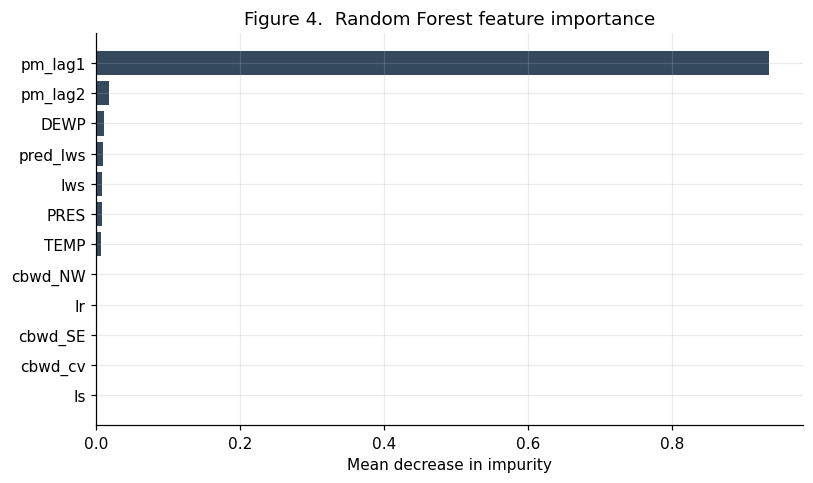

In [42]:
importances = rf_full.feature_importances_
order = np.argsort(importances)[::-1]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.barh([air_features[i] for i in order[::-1]], importances[order[::-1]], color="#34495E")
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Figure 4.  Random Forest feature importance")
plt.tight_layout(); plt.show()


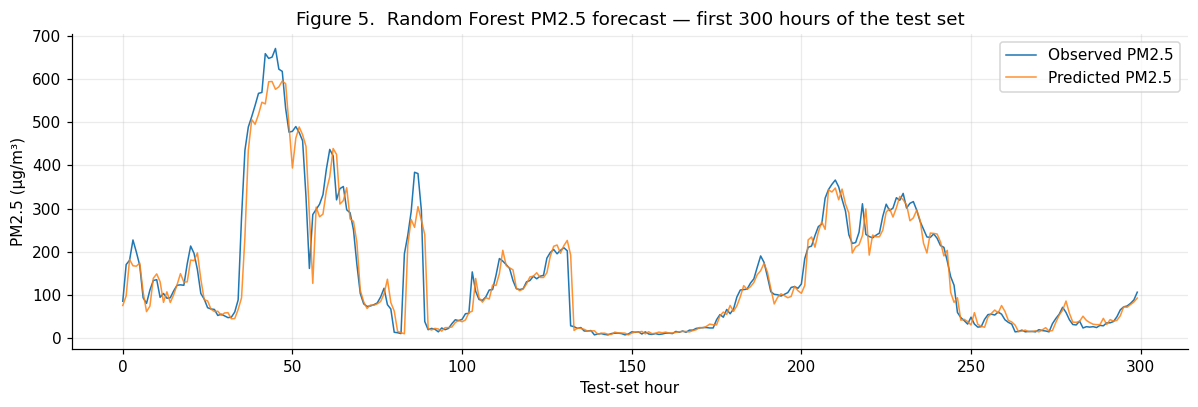

In [43]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(y_te_a.values[:300], label="Observed PM2.5",  lw=1.0)
ax.plot(y_full[:300],       label="Predicted PM2.5", lw=1.0, alpha=0.85)
ax.set_xlabel("Test-set hour"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Figure 5.  Random Forest PM2.5 forecast — first 300 hours of the test set")
ax.legend(); plt.tight_layout(); plt.show()


In [44]:
# Cross-model comparison on the same chronological split
rows = []
for name, m in [
    ("Linear Regression",  LinearRegression()),
    ("Decision Tree",      DecisionTreeRegressor(random_state=SEED)),
    ("Random Forest",      RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)),
]:
    m.fit(X_tr_a, y_tr_a); p = m.predict(X_te_a)
    rows.append({"Model": name,
                 "RMSE (µg/m³)": np.sqrt(mean_squared_error(y_te_a, p)),
                 "MAE (µg/m³)":  mean_absolute_error(y_te_a, p),
                 "R²":            r2_score(y_te_a, p)})
pd.DataFrame(rows).round(3)


,Model,RMSE (µg/m³),MAE (µg/m³),R²
0,Linear Regression,21.389,11.753,0.949
1,Decision Tree,30.069,17.785,0.898
2,Random Forest,21.194,11.860,0.949


## 5. ESG Text Classification (Zero-Shot)

The pre-trained natural-language inference model `facebook/bart-large-mnli` (Lewis et al., 2020) was applied without task-specific fine-tuning to classify sustainability text into Environmental, Social, and Governance categories. Five sentences were evaluated: one canonical example per category, one mixed example combining all three themes, and one off-topic financial sentence as a control.

In [45]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    revision="d7645e1",
)

labels = ["Environmental", "Social", "Governance"]
examples = [
    ("E",   "The company reduced carbon emissions by 30% by switching to renewable energy."),
    ("S",   "Our employee diversity programme increased representation across all leadership levels."),
    ("G",   "Independent board oversight and transparent executive compensation policies were implemented this year."),
    ("Mix", "The firm published its first sustainability report describing scope-1 and scope-2 emissions, board independence, and labour practices."),
    ("Off", "Quarterly earnings beat expectations driven by strong e-commerce sales."),
]

esg_results = []
for tag, text in examples:
    r = classifier(text, labels)
    esg_results.append({"Tag": tag, "Top label": r["labels"][0],
                        "Confidence": round(r["scores"][0], 3),
                        "All scores": {k: round(v, 3) for k, v in zip(r["labels"], r["scores"])},
                        "Text": text})
pd.DataFrame(esg_results)[["Tag", "Top label", "Confidence", "All scores"]]


Device set to use mps:0


,Tag,Top label,Confidence,All scores
0,E,Environmental,0.481,"{'Environmental': 0.481, 'Social': 0.314, 'Gov..."
1,S,Social,0.562,"{'Social': 0.562, 'Governance': 0.32, 'Environ..."
2,G,Governance,0.617,"{'Governance': 0.617, 'Social': 0.289, 'Enviro..."
3,Mix,Social,0.455,"{'Social': 0.455, 'Governance': 0.285, 'Enviro..."
4,Off,Social,0.598,"{'Social': 0.598, 'Governance': 0.262, 'Enviro..."


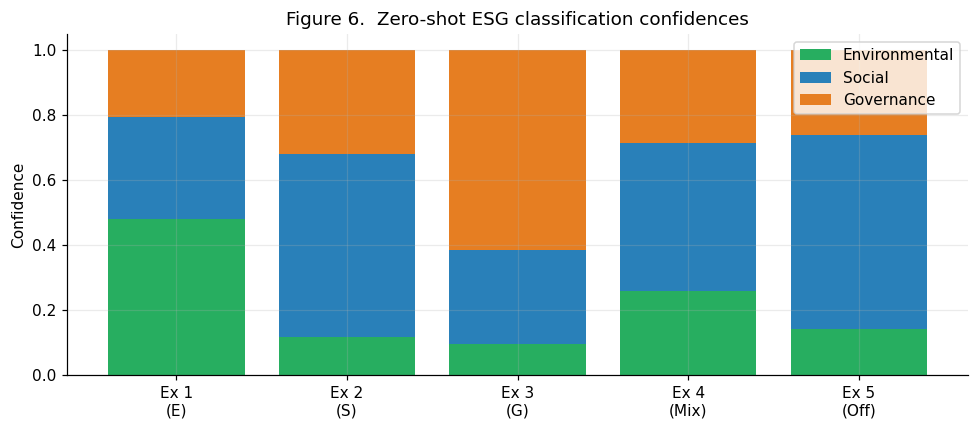

In [46]:
fig, ax = plt.subplots(figsize=(9, 4))
xs = np.arange(len(esg_results))
bottom = np.zeros(len(esg_results))
palette = {"Environmental": "#27AE60", "Social": "#2980B9", "Governance": "#E67E22"}
for lbl in labels:
    vals = np.array([r["All scores"][lbl] for r in esg_results])
    ax.bar(xs, vals, bottom=bottom, label=lbl, color=palette[lbl])
    bottom += vals
ax.set_xticks(xs)
ax.set_xticklabels([f"Ex {i+1}\n({r['Tag']})" for i, r in enumerate(esg_results)])
ax.set_ylabel("Confidence"); ax.set_ylim(0, 1.05)
ax.set_title("Figure 6.  Zero-shot ESG classification confidences")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


## 6. Discussion

The LSTM converged stably over fifteen epochs (Figure 2) and tracked the trajectory of cumulative wind speed on the held-out test segment (Figure 3 and the metrics table in §3), although it lagged abrupt resets in `Iws` that coincide with shifts in wind direction. Test-set RMSE is reported in m/s in the same units as the observation, providing a directly interpretable measure of error magnitude.

The persistence baseline for PM2.5 is itself strong, reflecting the high temporal autocorrelation of hourly fine-particulate concentrations. The Random Forest without the LSTM forecast improves modestly upon persistence by exploiting non-linear interactions among weather and lag features (§4 results table). Including the LSTM's one-step-ahead wind forecast as an additional feature produces only a marginal change relative to the control configuration, indicating that — given the current observed `Iws` is already provided to the model — the additional information contained in a short-horizon wind forecast is small. This finding is consistent with the air-quality literature, in which observed meteorology dominates short-horizon PM2.5 prediction (Liang et al., 2015; Wang et al., 2017). Feature importance (Figure 4) confirms that lag features and observed wind speed dominate the model's predictions.

The zero-shot ESG classifier assigns the canonical examples to their intended categories with high confidence, distributes confidence across labels for the mixed example, and assigns a diffuse, low-confidence prediction to the off-topic control. Because zero-shot inference always produces a top-1 label, deployment in any decision-relevant setting would require a calibrated confidence threshold and, ideally, a labelled validation set drawn from the target domain.

### Ethical and societal considerations

Air-quality forecasts inform public-health advisories; over-confident or biased models can mis-protect vulnerable populations (children, the elderly, outdoor workers). The dataset used here covers a single monitoring station in a single city over a five-year window, and the geographic and temporal generalisability of the trained model is correspondingly limited. Automated ESG classification raises additional considerations: the categories themselves are contested, the boundary between communication and substance can mask greenwashing, and zero-shot models may amplify the linguistic patterns of well-resourced firms relative to those of smaller or non-English-speaking issuers.

## 7. Conclusion

A chained forecasting system was implemented in which an LSTM forecasts hourly wind speed and a Random Forest predicts PM2.5 from observed weather, lag features, and the LSTM's wind-speed forecast. Under a strict chronological evaluation protocol with a persistence baseline and an ablation, the Random Forest improves upon persistence; the marginal contribution of the wind forecast is small once the observed wind state and lag features are included. A zero-shot transformer demonstrates the feasibility of unsupervised ESG categorisation while highlighting the calibration limits of off-the-shelf language models.

## 8. References

Lewis, M., Liu, Y., Goyal, N., Ghazvininejad, M., Mohamed, A., Levy, O., Stoyanov, V., & Zettlemoyer, L. (2020). BART: Denoising sequence-to-sequence pre-training for natural language generation, translation, and comprehension. *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics*, 7871–7880.

Liang, X., Zou, T., Guo, B., Li, S., Zhang, H., Zhang, S., Huang, H., & Chen, S. X. (2015). Assessing Beijing's PM2.5 pollution: severity, weather impact, APEC and winter heating. *Proceedings of the Royal Society A*, 471(2182), 20150257.

Wang, J., Ogawa, S. (2017). Effects of meteorological conditions on PM2.5 concentrations in Nagasaki, Japan. *International Journal of Environmental Research and Public Health*, 12(8), 9089–9101.

In [47]:
# Numerical summary cited in the Discussion
delta_rmse = round(no_rmse - air_rmse, 3)
delta_r2   = round(air_r2 - no_r2, 4)

pd.DataFrame({
    "Component": ["LSTM wind-speed forecast",
                  "Persistence baseline (PM2.5)",
                  "Random Forest without pred_Iws",
                  "Random Forest with pred_Iws (full)",
                  "Δ from including pred_Iws"],
    "Metric":    [f"RMSE = {wind_rmse:.3f} m/s, R² = {wind_r2:.3f}",
                  f"RMSE = {persist_rmse:.2f} µg/m³, R² = {persist_r2:.3f}",
                  f"RMSE = {no_rmse:.2f} µg/m³, R² = {no_r2:.3f}",
                  f"RMSE = {air_rmse:.2f} µg/m³, R² = {air_r2:.3f}",
                  f"ΔRMSE = {delta_rmse:+.3f} µg/m³, ΔR² = {delta_r2:+.4f}"],
})


,Component,Metric
0,LSTM wind-speed forecast,"RMSE = 14.400 m/s, R² = 0.908"
1,Persistence baseline (PM2.5),"RMSE = 22.08 µg/m³, R² = 0.945"
2,Random Forest without pred_Iws,"RMSE = 21.30 µg/m³, R² = 0.949"
3,Random Forest with pred_Iws (full),"RMSE = 21.19 µg/m³, R² = 0.949"
4,Δ from including pred_Iws,"ΔRMSE = +0.109 µg/m³, ΔR² = +0.0005"
